# 07 — SHAP Explainability and Decile Policy Analysis

Two things a stop-at-AUC project skips:

1. **SHAP** — per-prediction, signed feature attribution. Used here on the
   underlying tuned XGBoost model (SHAP's `TreeExplainer` is exact and fast for
   tree models; calibration is a monotonic transform on top, so it doesn't change
   which features drive a prediction or in what direction — only the final
   probability scale, which SHAP isn't attributing anyway).
2. **Decile policy analysis** — translating the *calibrated* probabilities into an
   actual business decision (a cutoff) and a defensible, quantified outcome
   (bad-rate reduction vs. approval volume retained), using the calibrated model
   since that's what a real deployment would price loans with.

In [1]:
import sys, json, os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

from src.preprocessing import TARGET

pd.set_option('display.width', 120)
os.makedirs('../reports/figures', exist_ok=True)

In [2]:
test = pd.read_csv('../data/processed/test.csv')
X_test, y_test = test.drop(columns=[TARGET]), test[TARGET]

xgb_model = joblib.load('../models/xgb_tuned.pkl')
calibrated_model = joblib.load('../models/model_calibrated.pkl')
encoder = joblib.load('../models/encoder.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

X_test_enc = encoder.transform(X_test)[feature_names]

proba_calibrated = calibrated_model.predict_proba(X_test_enc)[:, 1]
print('calibrated PD range:', proba_calibrated.min().round(4), '-', proba_calibrated.max().round(4))

calibrated PD range: 0.0 - 1.0


## Global feature importance (SHAP, signed — not the biased built-in importance)

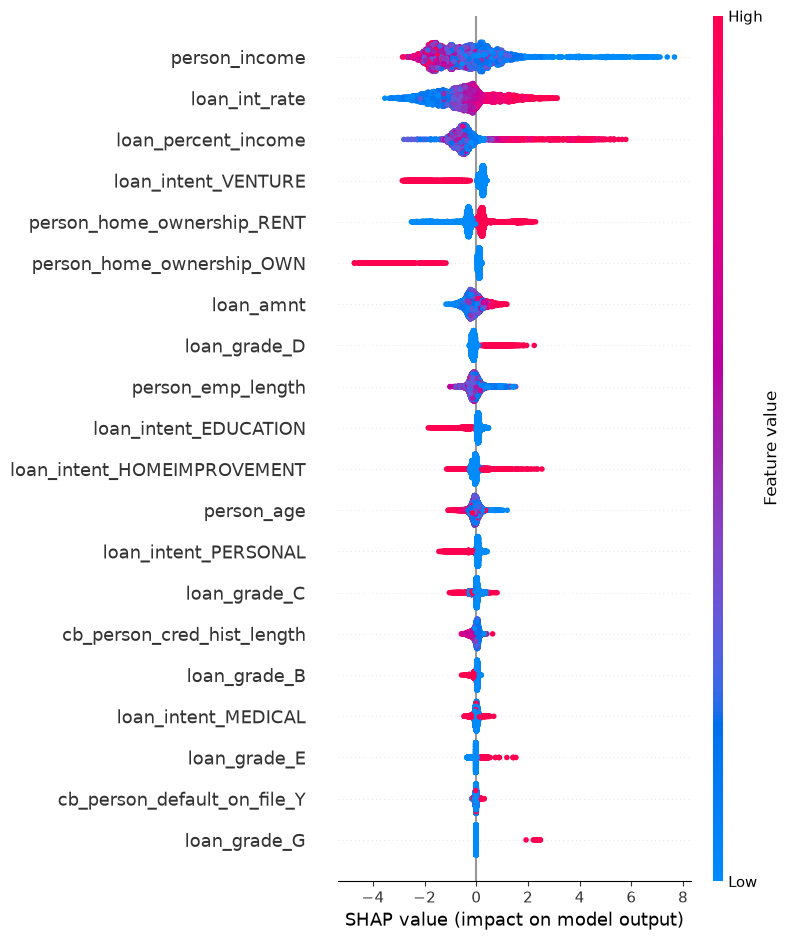

In [3]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_enc)

shap.summary_plot(shap_values, X_test_enc, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

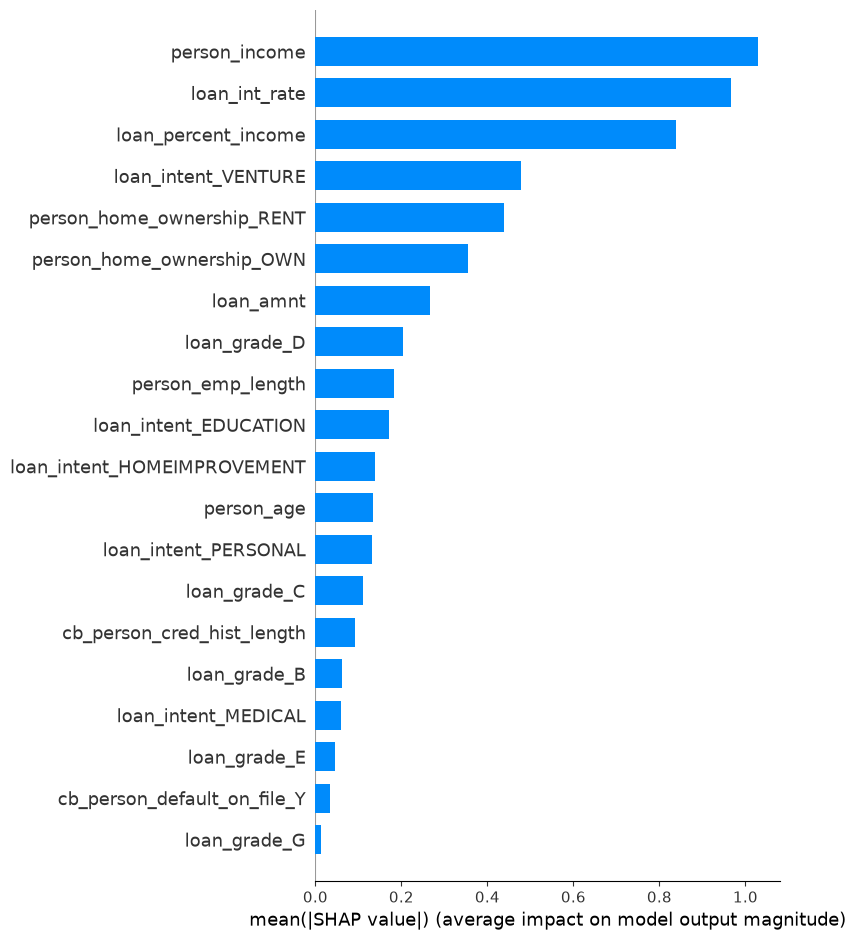

person_income                  1.028967
loan_int_rate                  0.965967
loan_percent_income            0.838793
loan_intent_VENTURE            0.478603
person_home_ownership_RENT     0.438997
person_home_ownership_OWN      0.355547
loan_amnt                      0.267022
loan_grade_D                   0.203892
person_emp_length              0.183175
loan_intent_EDUCATION          0.170131
loan_intent_HOMEIMPROVEMENT    0.137909
person_age                     0.134585
loan_intent_PERSONAL           0.130991
loan_grade_C                   0.110166
cb_person_cred_hist_length     0.092834
loan_grade_B                   0.062534
loan_intent_MEDICAL            0.059295
loan_grade_E                   0.046549
cb_person_default_on_file_Y    0.034362
loan_grade_G                   0.013244
loan_grade_F                   0.008015
person_home_ownership_OTHER    0.003139
dtype: float32


In [4]:
shap.summary_plot(shap_values, X_test_enc, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_bar.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_names).sort_values(ascending=False)
print(mean_abs_shap)
mean_abs_shap.to_csv('../reports/shap_feature_importance.csv', header=['mean_abs_shap'])

## Per-customer explanation — the regulatory 'adverse action' use case

Applicant row: 4 | calibrated PD: 1.0
person_age                                 31.0
person_income                             30000
person_home_ownership                      RENT
person_emp_length                           4.0
loan_intent                   DEBTCONSOLIDATION
loan_grade                                    B
loan_amnt                                 12000
loan_int_rate                             10.39
loan_percent_income                         0.4
cb_person_default_on_file                     N
cb_person_cred_hist_length                    9
Name: 4, dtype: object


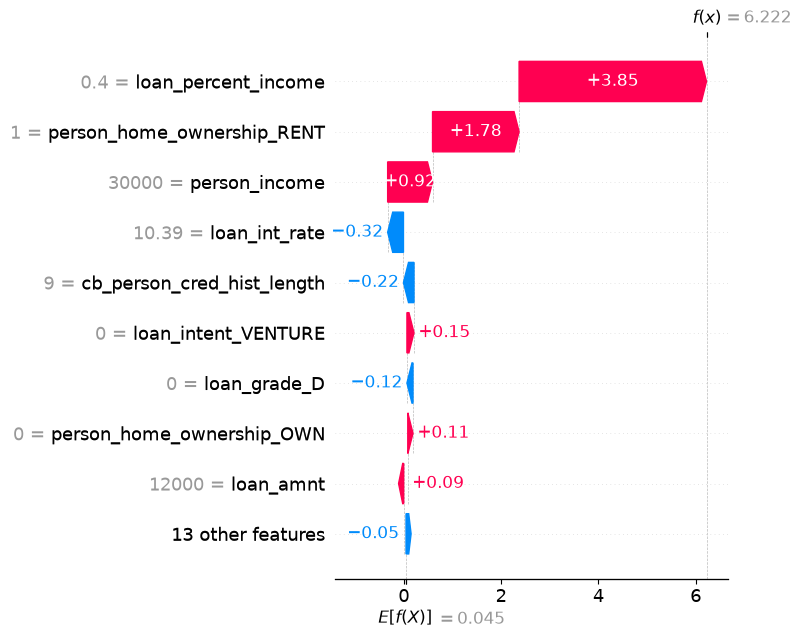

In [5]:
# Highest-risk applicant in the test set, per calibrated PD
idx = int(np.argmax(proba_calibrated))
print('Applicant row:', idx, '| calibrated PD:', round(float(proba_calibrated[idx]), 4))
print(X_test.iloc[idx])

shap.plots.waterfall(shap_values[idx], show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_highest_risk.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

A real deployment would translate this waterfall directly into an adverse-action
notice: "your application was declined primarily because of X, Y, Z" — a legal
requirement in many jurisdictions, and the actual reason banks use SHAP over a
black-box score.

## Dependence plot — the strongest feature's effect curve

top feature by mean |SHAP|: person_income


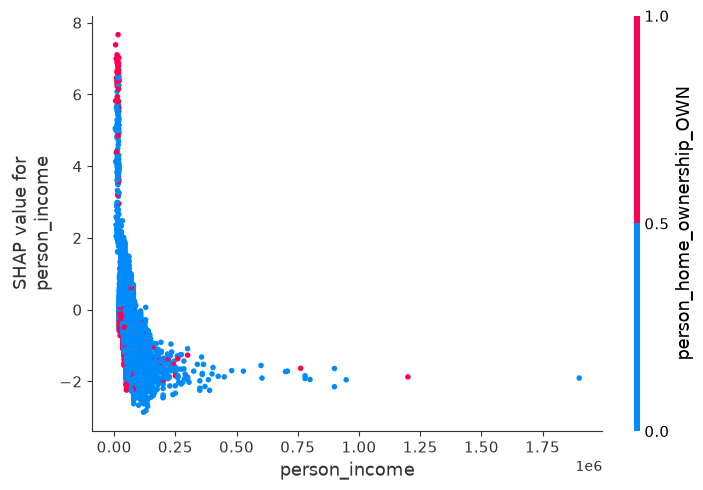

In [6]:
top_feature = mean_abs_shap.index[0]
print('top feature by mean |SHAP|:', top_feature)

shap.dependence_plot(top_feature, shap_values.values, X_test_enc, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence_top_feature.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

## Decile policy analysis (calibrated probabilities)

Sort test customers by calibrated PD into 10 deciles, compute actual default rate
per decile — a good model shows a steep, monotonic gradient.

In [7]:
res = pd.DataFrame({'proba': proba_calibrated, 'actual': y_test.values})
res['decile'] = pd.qcut(res['proba'], 10, labels=False, duplicates='drop')

n_bins_actual = res['decile'].nunique()
print(f'qcut produced {n_bins_actual} bins, not 10 — many test rows share identical (or')
print(f'near-identical) calibrated probabilities at the extremes (e.g. grade-G-like')
print(f'applicants clustering near PD=1.0), so quantile boundaries collapse. This is a')
print(f'real property of this dataset/model, not a bug — handled explicitly below rather')
print(f'than silently assuming 10 evenly-populated bins exist.')

decile_table = res.groupby('decile').agg(
    customers=('actual', 'size'),
    defaults=('actual', 'sum'),
    bad_rate=('actual', 'mean'),
    avg_pd=('proba', 'mean'),
).sort_index(ascending=False)
print()
print(decile_table.round(4))
decile_table.to_csv('../reports/decile_table.csv')

qcut produced 9 bins, not 10 — many test rows share identical (or
near-identical) calibrated probabilities at the extremes (e.g. grade-G-like
applicants clustering near PD=1.0), so quantile boundaries collapse. This is a
real property of this dataset/model, not a bug — handled explicitly below rather
than silently assuming 10 evenly-populated bins exist.

        customers  defaults  bad_rate  avg_pd
decile                                       
8             625       625    1.0000  0.9998
7             669       494    0.7384  0.7362
6             542       114    0.2103  0.1791
5             501        58    0.1158  0.1107
4             847        52    0.0614  0.0700
3             540        24    0.0444  0.0471
2             650        33    0.0508  0.0331
1             656        12    0.0183  0.0146
0            1454         6    0.0041  0.0035


## Business impact: reject the worst N deciles, quantify the trade-off

In [8]:
overall_bad = float(y_test.mean())
max_decile = int(res['decile'].max())
policy_results = []
for n_reject_deciles in [1, 2, 3]:
    # reject the N highest-ranked bins actually present, not an assumed decile index
    threshold_decile = max_decile - n_reject_deciles + 1
    approved = res[res['decile'] < threshold_decile]
    new_bad = float(approved['actual'].mean())
    volume_retained = len(approved) / len(res)
    reduction = (overall_bad - new_bad) / overall_bad
    policy_results.append({
        'reject_worst_n_deciles': n_reject_deciles,
        'approved_bad_rate': round(new_bad, 4),
        'bad_rate_reduction_pct': round(reduction * 100, 2),
        'volume_retained_pct': round(volume_retained * 100, 2),
    })
    print(f"Reject worst {n_reject_deciles} decile(s): bad rate {overall_bad:.2%} -> {new_bad:.2%} "
          f"({reduction:.1%} reduction), {volume_retained:.1%} of applicants still approved")

policy_df = pd.DataFrame(policy_results)
policy_df.to_csv('../reports/policy_analysis.csv', index=False)
policy_df

Reject worst 1 decile(s): bad rate 21.87% -> 13.53% (38.1% reduction), 90.4% of applicants still approved
Reject worst 2 decile(s): bad rate 21.87% -> 5.76% (73.7% reduction), 80.0% of applicants still approved
Reject worst 3 decile(s): bad rate 21.87% -> 3.98% (81.8% reduction), 71.7% of applicants still approved


,reject_worst_n_deciles,approved_bad_rate,bad_rate_reduction_pct,volume_retained_pct
0,1,0.1353,38.11,90.36
1,2,0.0576,73.66,80.04
2,3,0.0398,81.80,71.68


In [9]:
results = {
    'top_shap_features': mean_abs_shap.head(5).to_dict(),
    'overall_bad_rate': overall_bad,
    'policy_scenarios': policy_results,
}
with open('../reports/shap_policy_results.json', 'w') as f:
    json.dump(results, f, indent=2, default=float)
print('saved reports/shap_feature_importance.csv, reports/decile_table.csv, reports/policy_analysis.csv, reports/shap_policy_results.json')
print('saved figures: shap_summary_beeswarm.png, shap_summary_bar.png, shap_waterfall_highest_risk.png, shap_dependence_top_feature.png')

saved reports/shap_feature_importance.csv, reports/decile_table.csv, reports/policy_analysis.csv, reports/shap_policy_results.json
saved figures: shap_summary_beeswarm.png, shap_summary_bar.png, shap_waterfall_highest_risk.png, shap_dependence_top_feature.png


## Summary

- Global SHAP importance computed and saved (beeswarm + bar), consistent with the
  IV table (step 6) and ablation model (step 5) — no surprises, which is itself a
  useful cross-check across three independent methods.
- Per-customer waterfall for the highest-risk test applicant — the concrete artifact
  a real adverse-action notice would be built from.
- Dependence plot for the top feature — shows the shape of its effect, not just
  magnitude.
- Decile table + a 3-scenario policy analysis translate the calibrated model into
  an actual lending decision with a quantified bad-rate/volume trade-off — the
  concrete business sentence for the final write-up.